In [74]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
%matplotlib inline

In [75]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame[:]
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [76]:
print(df.info())
print("===========================================================================")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

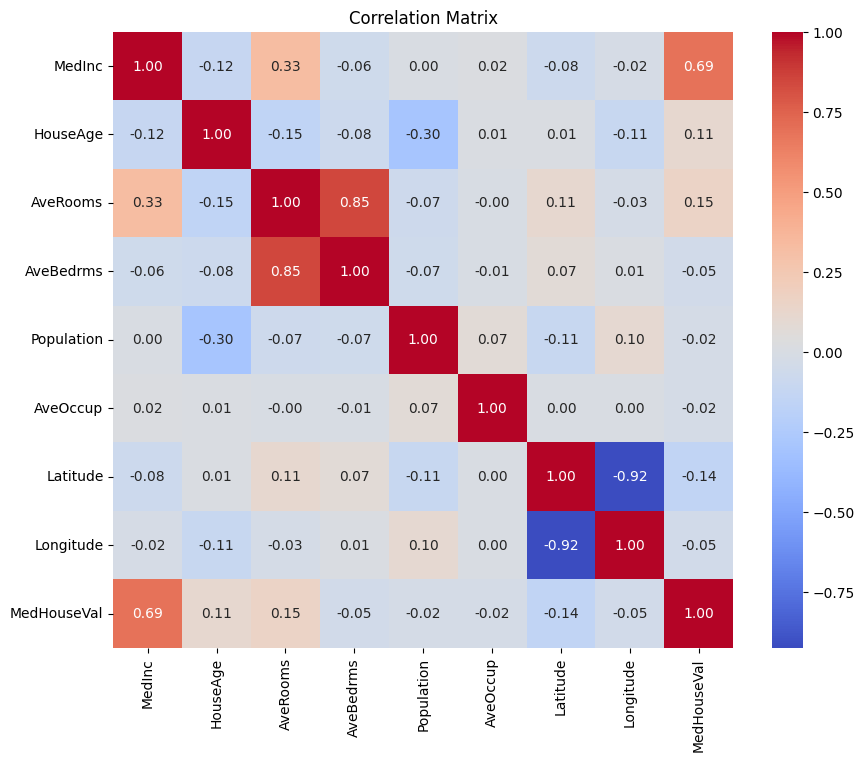

In [77]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [78]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42);

In [79]:
from sklearn.preprocessing import StandardScaler;
scaler = StandardScaler();
X_train_scaled = scaler.fit_transform(X_train);
X_test_scaled = scaler.transform(X_test);
print(X_train_scaled)
print("===================================")
print(X_test_scaled)

[[ 0.17648852  0.66640687 -0.06085431 ... -0.04828325 -0.8607415
   0.73099911]
 [ 0.77137436  1.06288858  0.38352076 ... -0.05872947  0.70916822
  -1.19670983]
 [ 0.02142423  0.58711053  0.27852339 ... -0.07283798  1.31370062
  -1.55128842]
 ...
 [-0.49582442  0.58711053 -0.5983225  ...  0.01885405 -0.75764295
   0.60115343]
 [ 0.96699069 -1.07811266  0.39633361 ...  0.0060417   0.90599273
  -1.1867217 ]
 [-0.68434939  1.855852   -0.83954627 ... -0.08347358  0.99503238
  -1.41644868]]
[[-1.15411223 -0.28514924 -0.51346718 ...  0.06447083  0.19367548
   0.28652736]
 [-0.70756701  0.11133247 -0.16361884 ... -0.03570466 -0.23746391
   0.06179445]
 [-0.20917611  1.855852   -0.6022714  ... -0.14606959  1.00909127
  -1.4264368 ]
 ...
 [-0.89908611  0.66640687 -0.89340574 ...  0.12360294 -0.76232924
   0.66108221]
 [ 1.58036659 -1.79177974  0.80393479 ... -0.04836253  1.34181841
  -0.73725589]
 [ 1.44652384  0.58711053  0.12349223 ... -0.04755791 -0.82325111
   0.5911653 ]]


In [80]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Intercept : ", model.intercept_)

Intercept :  2.0703489205426377


In [81]:
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

MedInc: 0.8521
HouseAge: 0.1207
AveRooms: -0.3021
AveBedrms: 0.3486
Population: -0.0016
AveOccup: -0.0412
Latitude: -0.8931
Longitude: -0.8678


In [82]:
y_pred = model.predict(X_test_scaled)
print(y_pred)   

[0.72412832 1.76677807 2.71151581 ... 1.72382152 2.34689276 3.52917352]


In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2Score = r2_score(y_test, y_pred)
print(mse)
print(mae)
print(r2Score)

0.5411287478470689
0.5296964012919461
0.5910509795491351


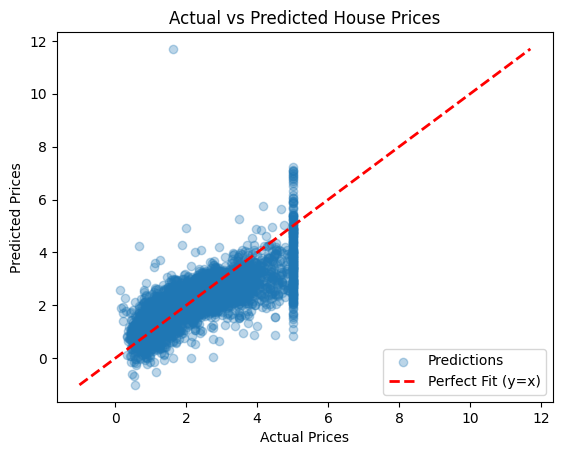

In [84]:
import numpy as np

plt.scatter(y_test, y_pred, alpha=0.3, label="Predictions")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

# Draw a diagonal line from min to max value of actual prices
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Fit (y=x)")

plt.legend()
plt.show()
